In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

processed_df = pd.read_csv('processed_ml_dataset.csv')

X = processed_df.drop(columns=['Painting_Target']).values.astype(float)
y = processed_df['Painting_Target'].values

unique_ids = raw_df['unique_id'].values

X_bin = (X > 0).astype(float)

print('X shape:', X_bin.shape)
print('y shape:', y.shape)
print('Unique respondents:', len(np.unique(unique_ids)))

X shape: (1686, 67)
y shape: (1686,)
Unique respondents: 562


In [39]:
# Shuffle and keep 20% for validation
all_respondents = np.arange(1, 563)
# Simple row-level 80/20 split to match other models
rng = np.random.default_rng(42)
indices = np.arange(len(y))
rng.shuffle(indices)

split = int(0.8 * len(indices))
X_train, y_train = X_bin[indices[:split]], y[indices[:split]]
X_val,   y_val   = X_bin[indices[split:]], y[indices[split:]]

print(f'Train: {X_train.shape[0]} rows')
print(f'Val:   {X_val.shape[0]} rows')

Train: 1348 rows
Val:   338 rows


In [40]:
def fit_bernoulli_nb(X, y, alpha=0.1):
    """
    Train a Bernoulli Naive Bayes classifier.

    Parameters
    ----------
    X     : (n_samples, n_features) binary numpy array
    y     : (n_samples,) integer class labels
    alpha : Laplace smoothing parameter (default 0.1)

    Returns
    -------
    classes     : array of unique class labels
    log_prior   : log P(c) for each class
    log_prob_1  : log P(x_j=1 | c) for each class and feature
    log_prob_0  : log P(x_j=0 | c) for each class and feature
    """
    classes    = np.unique(y)
    n_features = X.shape[1]
    n_classes  = len(classes)

    log_prior  = np.zeros(n_classes)
    log_prob_1 = np.zeros((n_classes, n_features))  # log P(x_j=1 | c)
    log_prob_0 = np.zeros((n_classes, n_features))  # log P(x_j=0 | c)

    for i, c in enumerate(classes):
        X_c = X[y == c]
        n_c = X_c.shape[0]

        log_prior[i] = np.log(n_c / len(y))

        # Laplace-smoothed feature probabilities
        feature_counts = X_c.sum(axis=0)
        p1 = (feature_counts + alpha) / (n_c + 2 * alpha)
        log_prob_1[i] = np.log(p1)
        log_prob_0[i] = np.log(1 - p1)

    return classes, log_prior, log_prob_1, log_prob_0


def predict_bernoulli_nb(X, classes, log_prior, log_prob_1, log_prob_0):
    """
    Predict class labels for samples in X.

    Parameters
    ----------
    X           : (n_samples, n_features) binary numpy array
    classes     : array of unique class labels (from fit)
    log_prior   : log P(c) for each class (from fit)
    log_prob_1  : log P(x_j=1 | c) (from fit)
    log_prob_0  : log P(x_j=0 | c) (from fit)

    Returns
    -------
    preds : (n_samples,) predicted class labels
    """
    log_likelihood = X @ log_prob_1.T + (1 - X) @ log_prob_0.T
    log_posterior  = log_likelihood + log_prior
    return classes[np.argmax(log_posterior, axis=1)]


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# Hyperparameter Tuning

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

train_accs = []
val_accs   = []

print(f"{'Alpha':>10}  {'Train Acc':>10}  {'Val Acc':>10}")
print('-' * 35)

for alpha in alphas:
    classes, log_prior, log_p1, log_p0 = fit_bernoulli_nb(X_train, y_train, alpha=alpha)
    tr = accuracy(y_train, predict_bernoulli_nb(X_train, classes, log_prior, log_p1, log_p0))
    va = accuracy(y_val,   predict_bernoulli_nb(X_val,   classes, log_prior, log_p1, log_p0))
    train_accs.append(tr)
    val_accs.append(va)
    print(f"{alpha:>10.3f}  {tr:>10.4f}  {va:>10.4f}")

best_alpha = alphas[np.argmax(val_accs)]
print(f'\nBest alpha: {best_alpha}  (val acc: {max(val_accs):.4f})')

     Alpha   Train Acc     Val Acc
-----------------------------------
     0.001      0.8346      0.8136
     0.010      0.8346      0.8136
     0.100      0.8353      0.8136
     0.500      0.8331      0.8107
     1.000      0.8316      0.8107
     2.000      0.8286      0.8136
     5.000      0.8234      0.8077
    10.000      0.8175      0.8018

Best alpha: 0.001  (val acc: 0.8136)


In [41]:
classes, log_prior, log_p1, log_p0 = fit_bernoulli_nb(X_train, y_train, alpha=best_alpha)

train_preds = predict_bernoulli_nb(X_train, classes, log_prior, log_p1, log_p0)
val_preds   = predict_bernoulli_nb(X_val,   classes, log_prior, log_p1, log_p0)

train_acc = accuracy(y_train, train_preds)
val_acc   = accuracy(y_val,   val_preds)

print(f'Training Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)')
print(f'Validation Accuracy: {val_acc:.4f}   ({val_acc*100:.2f}%)')

Training Accuracy:   0.8346 (83.46%)
Validation Accuracy: 0.8136   (81.36%)


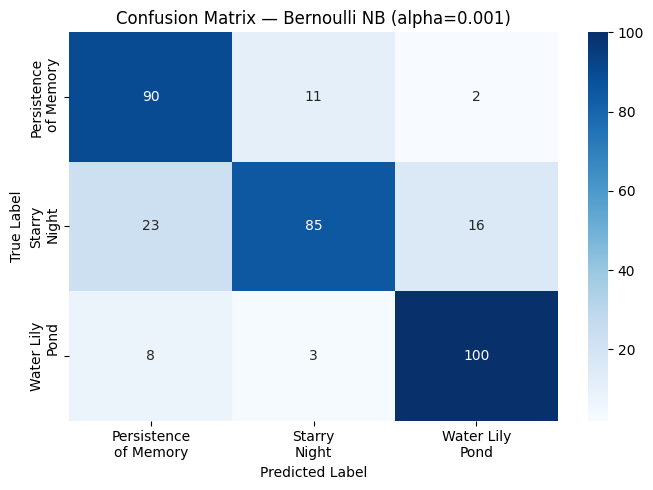


Per-class accuracy:
  The Persistence of Memory: 0.8738 (90/103)
  The Starry Night: 0.6855 (85/124)
  The Water Lily Pond: 0.9009 (100/111)


In [42]:
# Confusion matrix
n_classes = len(classes)
cm = np.zeros((n_classes, n_classes), dtype=int)
for true, pred in zip(y_val, val_preds):
    cm[true, pred] += 1

labels = ['Persistence\nof Memory', 'Starry\nNight', 'Water Lily\nPond']

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix — Bernoulli NB (alpha={best_alpha})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('nb_confusion_matrix.png', dpi=150)
plt.show()

print('\nPer-class accuracy:')
class_names = ['The Persistence of Memory', 'The Starry Night', 'The Water Lily Pond']
for i, name in enumerate(class_names):
    cls_acc = cm[i, i] / cm[i].sum()
    print(f'  {name}: {cls_acc:.4f} ({cm[i,i]}/{cm[i].sum()})')